In [2]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
SEED: int = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Data pipeline

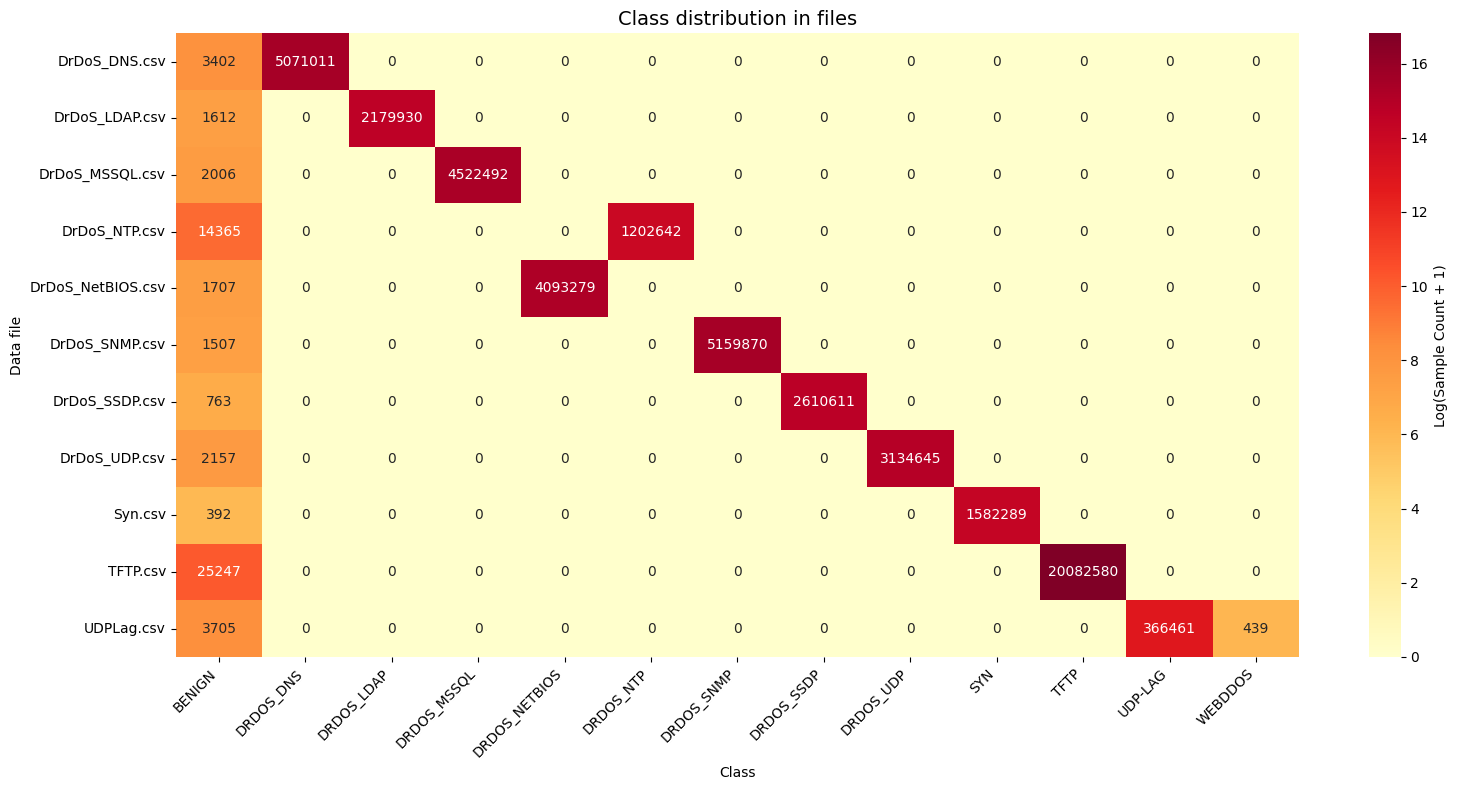

Class,BENIGN,DRDOS_DNS,DRDOS_LDAP,DRDOS_MSSQL,DRDOS_NETBIOS,DRDOS_NTP,DRDOS_SNMP,DRDOS_SSDP,DRDOS_UDP,SYN,TFTP,UDP-LAG,WEBDDOS
File,,,,,,,,,,,,,
DrDoS_DNS.csv,3402,5071011,0,0,0,0,0,0,0,0,0,0,0
DrDoS_LDAP.csv,1612,0,2179930,0,0,0,0,0,0,0,0,0,0
DrDoS_MSSQL.csv,2006,0,0,4522492,0,0,0,0,0,0,0,0,0
DrDoS_NTP.csv,14365,0,0,0,0,1202642,0,0,0,0,0,0,0
DrDoS_NetBIOS.csv,1707,0,0,0,4093279,0,0,0,0,0,0,0,0
DrDoS_SNMP.csv,1507,0,0,0,0,0,5159870,0,0,0,0,0,0
DrDoS_SSDP.csv,763,0,0,0,0,0,0,2610611,0,0,0,0,0
DrDoS_UDP.csv,2157,0,0,0,0,0,0,0,3134645,0,0,0,0
Syn.csv,392,0,0,0,0,0,0,0,0,1582289,0,0,0


In [3]:
def analyze_per_file_distribution(dir_path: str) -> pd.DataFrame:
    results = []
    for filename in sorted(os.listdir(dir_path)):
        if filename.endswith(".csv"):
            file_path = os.path.join(dir_path, filename)

            temp_cols = pd.read_csv(file_path, nrows=0).columns
            label_cols = [col for col in temp_cols if col.strip().lower() == "label"]

            if not label_cols:
                print(f"! Skipped {filename} - label column not found")
                continue

            label_col_name: str = label_cols[0]
            df_labels: pd.DataFrame = pd.read_csv(file_path, usecols=[label_col_name])
            clean_labels: pd.Series = df_labels[label_col_name].astype("str").str.strip().str.upper()

            counts = clean_labels.value_counts()
            for label, count in counts.items():
                results.append({"File": filename, "Class": label, "Count": count})

    df_results = pd.DataFrame(results)
    pivot_df = df_results.pivot(index="File", columns="Class", values="Count").fillna(0).astype(int)


    plt.figure(figsize=(16, 8))
    sns.heatmap(np.log1p(pivot_df), annot=pivot_df, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Log(Sample Count + 1)'})
    plt.title("Class distribution in files", fontsize=14)
    plt.ylabel("Data file")
    plt.xlabel("Class")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return pivot_df


DATA_DIR: str = "data/01-12"
analyze_per_file_distribution(DATA_DIR)


In [4]:
def load_dataset(path: str) -> pd.DataFrame:
    return pd.read_csv(path)

def filter_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Removes network-specific socket features and junk columns
    to prevent model overfitting.
    """
    df.columns = df.columns.str.strip()
    columns_to_drop: list[str] = [
        'Unnamed: 0',
        'Flow ID',
        'Source IP',
        'Source Port',
        'Destination IP',
        'Destination Port',
        'Timestamp',
        'Fwd Header Length.1',
        'SimillarHTTP',
        'Inbound'
    ]
    existing_columns_to_drop: list[str] = [col for col in columns_to_drop if col in df.columns]
    filtered_df: pd.DataFrame = df.drop(existing_columns_to_drop, axis=1)

    return filtered_df

def clean_missing_and_infinite_values(df: pd.DataFrame) -> pd.DataFrame:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(axis=0, how="any", inplace=True)

    return df

In [5]:
from sklearn.preprocessing import LabelEncoder

def encode_multiclass_labels(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """
    Encodes text labels to integers (0, 1, 2...).
    Returns the updated DataFrame and the class mapping dictionary.
    """
    df["Label"] = df["Label"].astype(str).str.strip().str.upper()
    label_encoder = LabelEncoder()
    df["Label"] = label_encoder.fit_transform(df["Label"])
    encoded_keys = label_encoder.transform(label_encoder.classes_)
    class_names = label_encoder.classes_
    mapping = {int(k): str(v) for k, v in zip(encoded_keys, class_names)}

    return df, mapping


def build_balanced_multiclass_dataset(directory_path: str, global_max_per_class: int = 20_000) -> tuple[pd.DataFrame, dict]:
    """
    Creates multi-class dataset, taking as a whole underrepresented classes.
    Returns the master DataFrame and the class mapping dictionary.
    """
    processed_dfs = []

    for filename in sorted(os.listdir(directory_path)):
        if filename.endswith(".csv"):
            file_path = os.path.join(directory_path, filename)
            print(f"Loading: {filename}...")

            temp_df = load_dataset(file_path)
            temp_df = filter_features(temp_df)
            temp_df = clean_missing_and_infinite_values(temp_df)
            temp_df["Label"] = temp_df["Label"].astype(str).str.strip().str.upper()

            for _, group_df in temp_df.groupby("Label"):
                if len(group_df) > global_max_per_class:
                    processed_dfs.append(group_df.sample(n=global_max_per_class, random_state=SEED))
                else:
                    processed_dfs.append(group_df)

    print("\nMerging into global dataset...")
    master_df = pd.concat(processed_dfs, ignore_index=True)

    # final_pieces = []
    # for class_name, group_df in global_df.groupby("Label"):
    #     if len(group_df) > global_max_per_class:
    #         final_pieces.append(group_df.sample(n=global_max_per_class, random_state=SEED))
    #     else:
    #         final_pieces.append(group_df)
    # master_df = pd.concat(final_pieces, ignore_index=True)

    master_df = master_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    print("Applying label encoding...")
    master_df, class_mapping = encode_multiclass_labels(master_df)

    return master_df, class_mapping

In [6]:
import json

DATA_DIR: str = "data/01-12"
MASTER_DATASET_PATH: str = "data/master_clean_dataset.csv"
MAPPING_PATH: str = "data/class_mapping.json"

if os.path.exists(MASTER_DATASET_PATH) and os.path.exists(MAPPING_PATH):
    print("Loading cached dataset and mapping...")
    master_df: pd.DataFrame = pd.read_csv(MASTER_DATASET_PATH)
    with open(MAPPING_PATH, "r") as f:
        loaded_mapping = json.load(f)
        class_mapping: dict = {int(k): v for k, v in loaded_mapping.items()}

else:
    print("Building dataset...")
    master_df, class_mapping = build_balanced_multiclass_dataset(DATA_DIR, global_max_per_class=20_000)

    master_df.to_csv(MASTER_DATASET_PATH, index=False)
    print(f"Dataset saved to {MASTER_DATASET_PATH}")
    with open(MAPPING_PATH, "w") as f:
        json.dump(class_mapping, f, indent=4)
    print(f"Class mapping saved to {MAPPING_PATH}")

print("\n--- FINAL MULTI-CLASS DISTRIBUTION ---")
print(master_df["Label"].value_counts().sort_index())

print("\n--- CLASS MAPPING ---")
for encoded_val, original_name in class_mapping.items():
    print(f"Class {encoded_val} -> {original_name}")

print("\nDataset shape:", master_df.shape)


Loading cached dataset and mapping...

--- FINAL MULTI-CLASS DISTRIBUTION ---
Label
0     51330
1     20000
2     20000
3     20000
4     20000
5     20000
6     20000
7     20000
8     20000
9     20000
10    20000
11    20000
12      439
Name: count, dtype: int64

--- CLASS MAPPING ---
Class 0 -> BENIGN
Class 1 -> DRDOS_DNS
Class 2 -> DRDOS_LDAP
Class 3 -> DRDOS_MSSQL
Class 4 -> DRDOS_NETBIOS
Class 5 -> DRDOS_NTP
Class 6 -> DRDOS_SNMP
Class 7 -> DRDOS_SSDP
Class 8 -> DRDOS_UDP
Class 9 -> SYN
Class 10 -> TFTP
Class 11 -> UDP-LAG
Class 12 -> WEBDDOS

Dataset shape: (271769, 78)


In [7]:
class_mapping

{0: 'BENIGN',
 1: 'DRDOS_DNS',
 2: 'DRDOS_LDAP',
 3: 'DRDOS_MSSQL',
 4: 'DRDOS_NETBIOS',
 5: 'DRDOS_NTP',
 6: 'DRDOS_SNMP',
 7: 'DRDOS_SSDP',
 8: 'DRDOS_UDP',
 9: 'SYN',
 10: 'TFTP',
 11: 'UDP-LAG',
 12: 'WEBDDOS'}

In [8]:
def split_dataframe(df: pd.DataFrame, train_frac: float = 0.7) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    X: np.ndarray = df.drop("Label", axis=1).values
    y: np.ndarray = df["Label"].values

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(1.0-train_frac), random_state=SEED, stratify=y
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
    )

    return X_train, y_train, X_val, y_val, X_test, y_test

def normalize(X_train: np.ndarray, X_val: np.ndarray, X_test: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    scaler: MinMaxScaler = MinMaxScaler(feature_range=(0,1))
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_val_scaled, X_test_scaled

X_train, y_train, X_val, y_val, X_test, y_test = split_dataframe(master_df)
X_train, X_val, X_test = normalize(X_train, X_val, X_test)



In [9]:
class DDOSDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index: int):
        return self.X[index], self.y[index]

In [10]:
train_dataset = DDOSDataset(X_train, y_train)
valid_dataset = DDOSDataset(X_val, y_val)
test_dataset = DDOSDataset(X_test, y_test)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
sample_inputs, sample_labels = next(iter(train_loader))
input_dim = sample_inputs.shape[-1]
input_dim

77

In [12]:
import gc

del master_df
gc.collect()

0

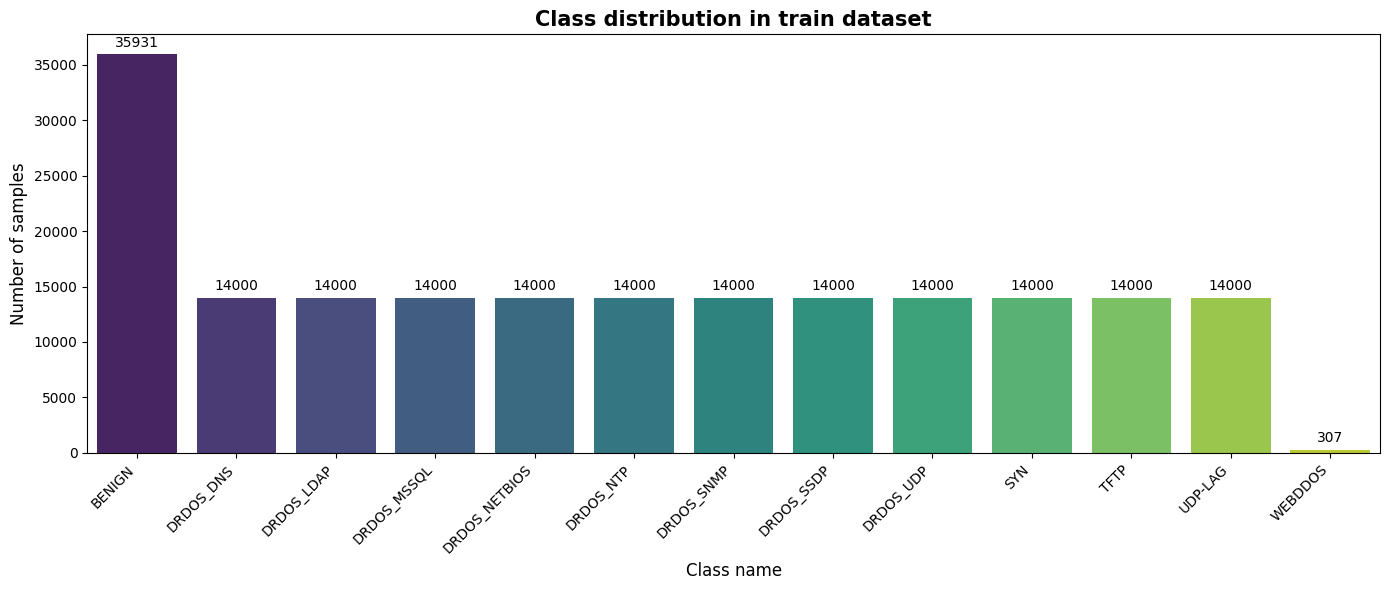

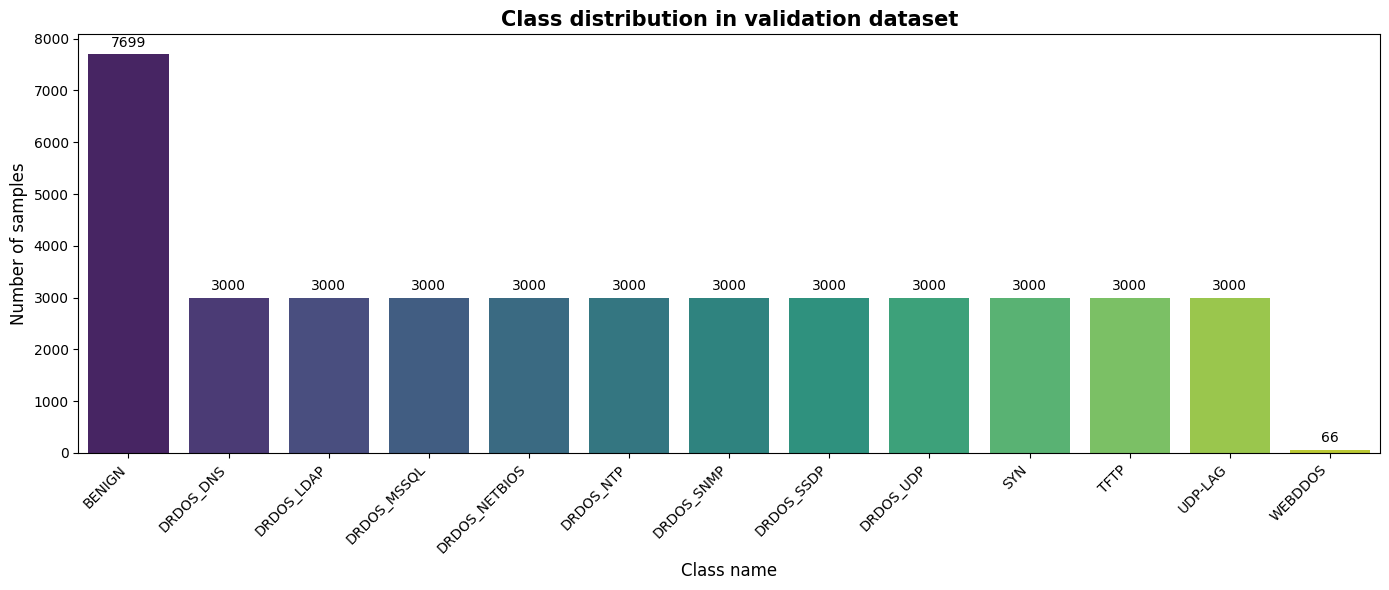

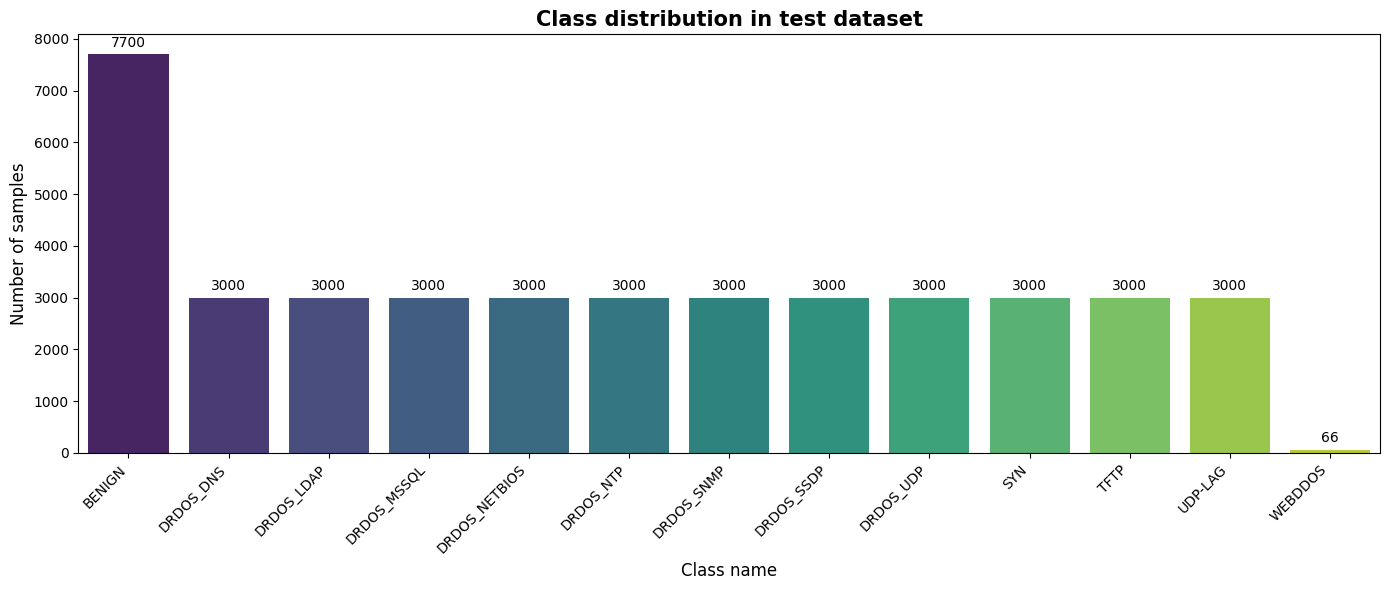

In [13]:
def plot_dataset_distribution(y_tensor: torch.Tensor, class_mapping: dict, dataset_name: str):
    """
    Generates a bar chart showing class distribution with original class names.
    """
    counts = pd.Series(y_tensor.numpy()).value_counts().sort_index()
    counts.index = counts.index.map(class_mapping)

    plt.figure(figsize=(14, 6))
    ax = sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="viridis", legend=False)

    plt.title(f"Class distribution in {dataset_name}", fontsize=15, fontweight='bold')
    plt.xlabel("Class name", fontsize=12)
    plt.ylabel("Number of samples", fontsize=12)
    plt.xticks(rotation=45, ha='right')

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom',
                    xytext=(0, 3),
                    textcoords='offset points',
                    fontsize=10)

    plt.tight_layout()
    plt.show()

plot_dataset_distribution(train_dataset.y, class_mapping, dataset_name="train dataset")
plot_dataset_distribution(valid_dataset.y, class_mapping, dataset_name="validation dataset")
plot_dataset_distribution(test_dataset.y, class_mapping, dataset_name="test dataset")

# Modele

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy

print(f"Dostępność GPU: {torch.cuda.is_available()}")

Dostępność GPU: True


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )
device

device(type='cuda')

## Klasy modeli

In [16]:
class DDOS_DNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DDOS_DNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3), 
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        if x.dim() == 3 and x.size(1) == 1:
            x = x.squeeze(1)
        return self.network(x)

## Trenowanie

In [17]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

### Funkcje trenujące 

In [18]:
from sklearn.utils.class_weight import compute_class_weight

def finetune_classifier(model, train_loader, val_loader, device, epochs=50, lr=0.0001):
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    criterion = nn.CrossEntropyLoss(weight=weights)
    # criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    reduce_lr = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )

    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())

    train_losses = [None]*epochs
    val_losses = [None]*epochs
    train_acc = [None]*epochs
    val_acc = [None]*epochs

    model.to(device)

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader):
            inputs, labels = inputs.to(device), labels.to(device).long()
            if inputs.dim() == 2:
                inputs = inputs.unsqueeze(1)


            optimizer.zero_grad()

            logits = model(inputs)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        epoch_train_loss = train_loss / total
        epoch_train_acc = train_correct / total
        train_losses[epoch] = epoch_train_loss
        train_acc[epoch] = epoch_train_acc

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).long()
                if inputs.dim() == 2:
                    inputs = inputs.unsqueeze(1)

                logits = model(inputs)
                loss = criterion(logits, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(logits.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        val_losses[epoch] = epoch_val_loss
        val_acc[epoch] = epoch_val_acc

        reduce_lr.step(val_loss)

        print(f'Fine-tuning Epoch {epoch+1}/{epochs} | '
              f'Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | '
              f'Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}')

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_weights)
    return model, (train_losses, val_losses), (train_acc, val_acc)


In [25]:
def finetune_classifier2(model, train_loader, val_loader, device, epochs=50, lr=0.0001):
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    reduce_lr = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )

    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())

    train_losses = [None]*epochs
    val_losses = [None]*epochs
    train_acc = [None]*epochs
    val_acc = [None]*epochs

    model.to(device)

    epoch_bar = tqdm(range(epochs), desc="Trening modelu")
    for epoch in epoch_bar:
        model.train()
        train_loss, train_correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).long()
            if inputs.dim() == 2:
                inputs = inputs.unsqueeze(1)

            optimizer.zero_grad()

            logits = model(inputs)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        epoch_train_loss = train_loss / total
        epoch_train_acc = train_correct / total
        train_losses[epoch] = epoch_train_loss
        train_acc[epoch] = epoch_train_acc

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).long()
                if inputs.dim() == 2:
                    inputs = inputs.unsqueeze(1)

                logits = model(inputs)
                loss = criterion(logits, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(logits.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        val_losses[epoch] = epoch_val_loss
        val_acc[epoch] = epoch_val_acc

        reduce_lr.step(val_loss)

        epoch_bar.set_postfix({
            'train_acc': f"{train_acc[epoch]:.4f}", 
            'val_acc': f"{val_acc[epoch]:.4f}"
        })

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_weights)
    return model, (train_losses, val_losses), (train_acc, val_acc)


In [19]:
def plot_learning_curves(train_losses, val_losses):
    """
    Rysuje wykres błędu treningowego i walidacyjnego.
    train_losses: lista wartości avg_train_loss z kolejnych epok
    val_losses: lista wartości avg_val_loss z kolejnych epok
    """
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, train_losses, 'b-', label='Trening (Train Loss)', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, val_losses, 'r-', label='Walidacja (Val Loss)', linewidth=2, marker='s', markersize=4)

    plt.title('Krzywe uczenia modelu', fontsize=14, pad=15)
    plt.xlabel('Epoki', fontsize=12)
    plt.ylabel('Strata (Loss - MSE)', fontsize=12)

    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.xticks(epochs)

    plt.tight_layout()
    plt.show()


In [20]:
def plot_accuracy_curves(train_accs, val_accs):
    """
    Rysuje wykres dokładności treningowej i walidacyjnej.
    train_accs: lista wartości avg_train_acc z kolejnych epok
    val_accs: lista wartości avg_val_acc z kolejnych epok
    """
    epochs = range(1, len(train_accs) + 1)
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, train_accs, 'g-', label='Trening (Train Acc)', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, val_accs, 'darkorange', label='Walidacja (Val Acc)', linewidth=2, marker='s', markersize=4)

    plt.title('Krzywe dokładności modelu (Accuracy)', fontsize=14, pad=15)
    plt.xlabel('Epoki', fontsize=12)
    plt.ylabel('Dokładność (Accuracy)', fontsize=12)

    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.xticks(epochs)

    # plt.ylim(0.0, 1.05)

    plt.tight_layout()
    plt.show()

In [21]:
def evaluate_and_plot_confusion_matrix(model, test_loader, device, class_mapping):
    """
    Ewaluacja modelu (multi-class) + macierz pomyłek.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            inputs = inputs.unsqueeze(1)
            logits = model(inputs)

            predicted = torch.argmax(logits, dim=1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"\nAccuracy na zbiorze testowym: {acc:.4f}")

    labels_sorted = sorted(class_mapping.keys())
    class_names = [class_mapping[i] for i in labels_sorted]

    print("\nRaport klasyfikacji:")
    print(classification_report(
        all_labels,
        all_preds,
        labels=labels_sorted,
        target_names=class_names,
        zero_division=0
    ))

    cm = confusion_matrix(all_labels, all_preds, labels=labels_sorted)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=True,
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title('Macierz Pomyłek - Multi-Class (Test)', fontsize=14)
    plt.ylabel('Prawdziwe etykiety')
    plt.xlabel('Przewidziane etykiety')

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [22]:
import torch.nn.functional as F
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

def compute_multiclass_auc(model, test_loader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if inputs.dim() == 2:
                inputs = inputs.unsqueeze(1)

            logits = model(inputs)
            probs = F.softmax(logits, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    y_bin = label_binarize(all_labels, classes=list(range(all_probs.shape[1])))

    macro_auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')
    micro_auc = roc_auc_score(y_bin, all_probs, average='micro', multi_class='ovr')

    print(f"Macro AUC: {macro_auc:.4f}")
    print(f"Micro AUC: {micro_auc:.4f}")

### Trenowanie klasyfikacji

In [61]:
classifier_model = DDOS_DNN(input_dim=input_dim, num_classes=len(class_mapping)).to(device)

In [62]:
final_model, losses2, accuraties = finetune_classifier(classifier_model, train_loader, val_loader, device, epochs=50, lr=0.0001)

  0%|          | 0/5945 [00:00<?, ?it/s]

100%|██████████| 5945/5945 [00:13<00:00, 454.84it/s]


Fine-tuning Epoch 1/50 | Train Loss: 1.0184 Acc: 0.6130 | Val Loss: 0.7058 Acc: 0.6979


100%|██████████| 5945/5945 [00:13<00:00, 440.91it/s]


Fine-tuning Epoch 2/50 | Train Loss: 0.7724 Acc: 0.6740 | Val Loss: 0.6819 Acc: 0.7049


...

Fine-tuning Epoch 48/50 | Train Loss: 0.6156 Acc: 0.7367 | Val Loss: 0.5852 Acc: 0.7478


100%|██████████| 5945/5945 [00:12<00:00, 473.50it/s]


Fine-tuning Epoch 49/50 | Train Loss: 0.6136 Acc: 0.7379 | Val Loss: 0.5850 Acc: 0.7485


100%|██████████| 5945/5945 [00:16<00:00, 356.49it/s]


Fine-tuning Epoch 50/50 | Train Loss: 0.6146 Acc: 0.7373 | Val Loss: 0.5821 Acc: 0.7447


In [63]:
torch.save(final_model.state_dict(), os.path.join("./saved_models", "best_multiclassifier_v2.pth"))

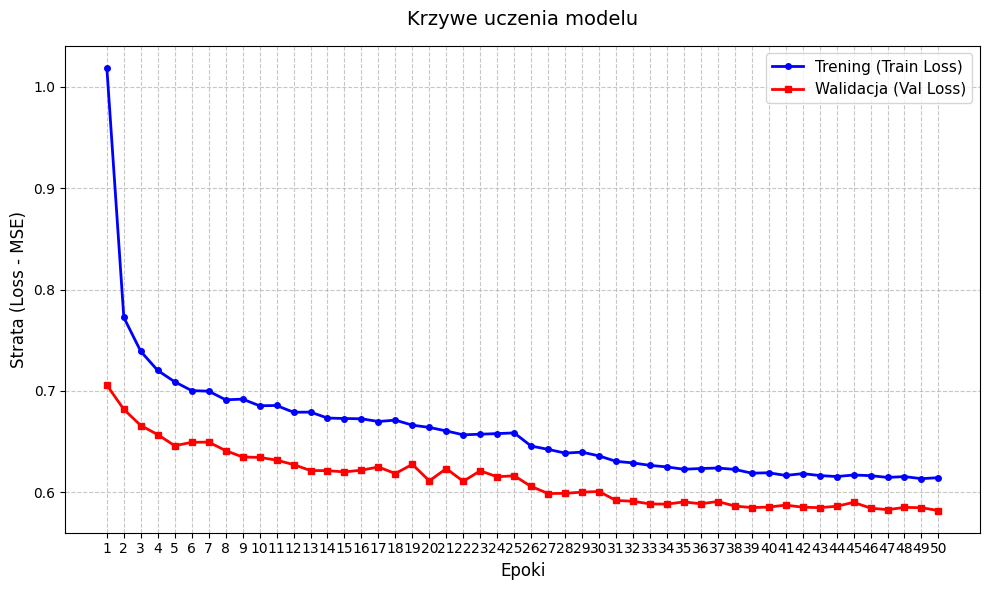

In [64]:
plot_learning_curves(*losses2)

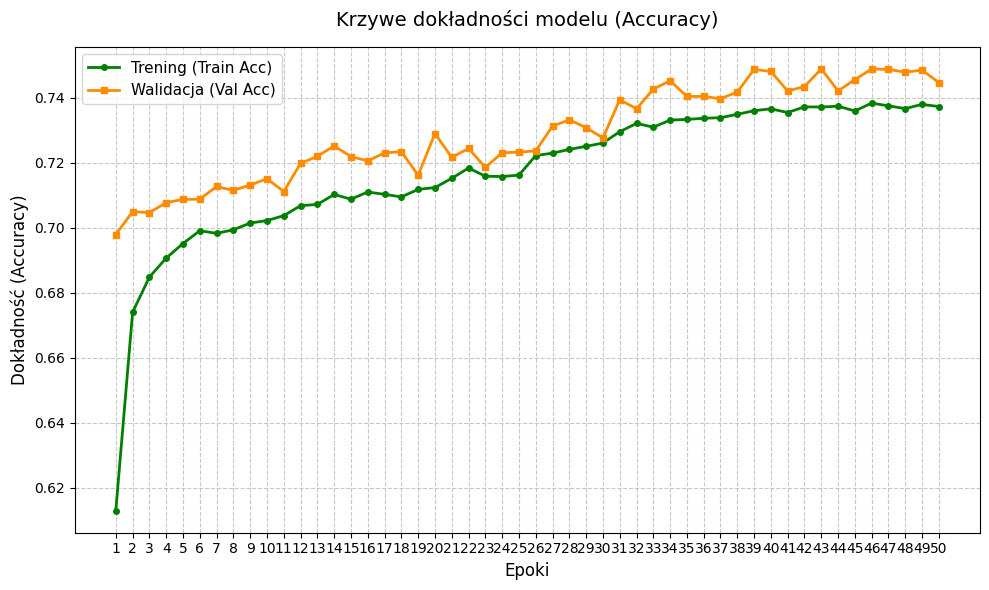

In [65]:
plot_accuracy_curves(*accuraties)


Accuracy na zbiorze testowym: 0.7444

Raport klasyfikacji:
               precision    recall  f1-score   support

       BENIGN       1.00      0.98      0.99      7700
    DRDOS_DNS       0.48      0.77      0.59      3000
   DRDOS_LDAP       0.52      0.03      0.05      3000
  DRDOS_MSSQL       0.88      0.86      0.87      3000
DRDOS_NETBIOS       0.95      0.99      0.97      3000
    DRDOS_NTP       0.99      0.95      0.97      3000
   DRDOS_SNMP       0.62      0.84      0.72      3000
   DRDOS_SSDP       0.47      0.03      0.05      3000
    DRDOS_UDP       0.46      0.96      0.63      3000
          SYN       0.60      1.00      0.75      3000
         TFTP       0.94      0.99      0.97      3000
      UDP-LAG       0.99      0.18      0.30      3000
      WEBDDOS       0.32      0.92      0.48        66

     accuracy                           0.74     40766
    macro avg       0.71      0.73      0.64     40766
 weighted avg       0.77      0.74      0.69     40766



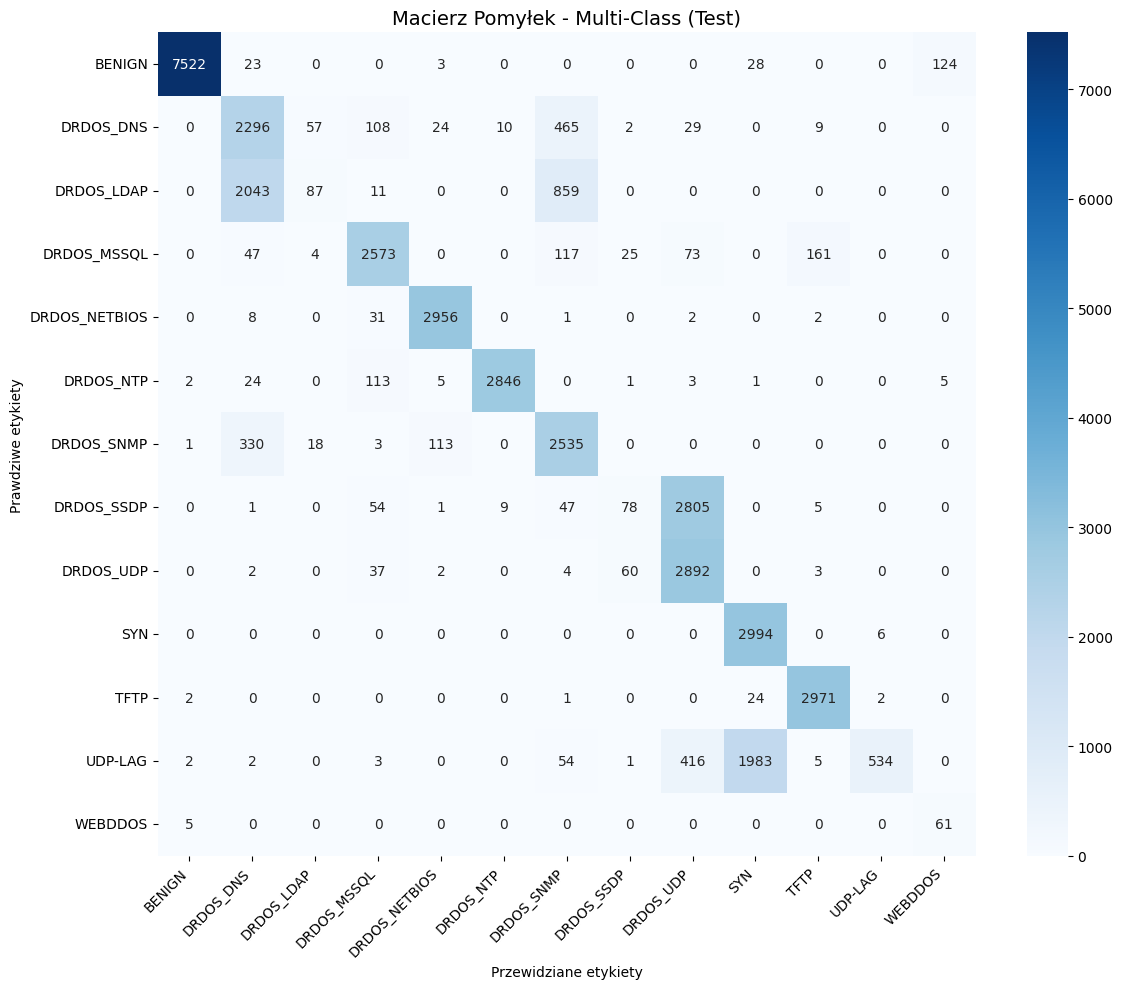

In [66]:
evaluate_and_plot_confusion_matrix(final_model, test_loader, device, class_mapping)

In [67]:
compute_multiclass_auc(final_model, test_loader, device)

Macro AUC: 0.9751
Micro AUC: 0.9864


## Testy

In [23]:
lrs = [0.1, 0.01, 0.001, 0.0001, 0.00005]

In [24]:
results = []
best_val_acc = 0.0
best_model_weights = None
best_lr = None

In [27]:
for i, lr in enumerate(lrs):
    print(f"--- Trening {i+1}/{len(lrs)} | Ustawienia: {lr=} ---")

    current_model = DDOS_DNN(input_dim=input_dim, num_classes=len(class_mapping)).to(device).to(device)
    
    trained_model, (train_losses, val_losses), (train_acc, val_acc) = finetune_classifier2(
        model=current_model, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        device=device, 
        epochs=40, 
        lr=lr
    )
    
    current_best_acc = max(val_acc) if len(val_acc) > 0 else 0
    current_min_loss = min(val_losses) if len(val_losses) > 0 else 0
    
    results.append({
        'lr': lr,
        'best_val_loss': current_min_loss,
        'best_val_acc': current_best_acc
    })
    
    if current_best_acc > best_val_acc:
        best_val_acc = current_best_acc
        best_lr = lr
        best_model_weights = copy.deepcopy(trained_model.state_dict())

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='best_val_acc', ascending=False).reset_index(drop=True)

print("\n================ PODSUMOWANIE WYNIKÓW ================")
print(results_df.to_string())
print("======================================================")

print(f"\nNajlepszy lr to: {best_lr}")
print(f"Uzyskana dokładność na zbiorze walidacyjnym: {best_val_acc:.4f}")

--- Trening 1/5 | Ustawienia: lr=0.1 ---


Trening modelu: 100%|██████████| 40/40 [15:23<00:00, 23.10s/it, train_acc=0.1889, val_acc=0.1884]


--- Trening 2/5 | Ustawienia: lr=0.01 ---


Trening modelu: 100%|██████████| 40/40 [15:16<00:00, 22.90s/it, train_acc=0.6722, val_acc=0.7010]


--- Trening 3/5 | Ustawienia: lr=0.001 ---


...

--- Trening 4/5 | Ustawienia: lr=0.0001 ---


Trening modelu: 100%|██████████| 40/40 [12:34<00:00, 18.87s/it, train_acc=0.7361, val_acc=0.7429]


--- Trening 5/5 | Ustawienia: lr=5e-05 ---


Trening modelu: 100%|██████████| 40/40 [09:18<00:00, 13.97s/it, train_acc=0.7340, val_acc=0.7358]


================ PODSUMOWANIE WYNIKÓW ================
        lr  best_val_loss  best_val_acc
0  0.00005       0.588421      0.745959
1  0.00010       0.585294      0.745713
2  0.00100       0.604803      0.730602
3  0.01000       0.681414      0.702833
4  0.10000      13.645525      0.188618

Najlepszy lr to: 5e-05
Uzyskana dokładność na zbiorze walidacyjnym: 0.7460
